# Winter wheat yield — TorchCrop against GDHY (gridded)

**What this notebook does.** It bins the 10 km TorchCrop winter-wheat yield
simulation onto the 0.5° grid of GDHY (Iizumi & Sakai 2020), pairs the two
fields per grid cell and year, and reports the same skill metrics as
[`yield_evaluation.ipynb`](yield_evaluation.ipynb) — but spatially resolved
rather than collapsed to 23 national means.

**Why a second yield notebook.** CyBench evaluates at the level a country runs
its statistics service at; GDHY evaluates at the level the model actually
predicts. The two ask different questions and can disagree: a country-level
bias can hide entirely opposite errors in its western and eastern halves, and
this notebook is where that would show up.

**Three conventions worth knowing before reading any number:**

1. **Error is `simulated − observed`.** A negative bias means the model is low.
2. **GDHY is not an observation of the grid cell**, it downscales national and
   sub-national statistics with a satellite vegetation-index proxy and a crop
   mask. A cell's *level* is largely its country's statistic; what varies
   between neighbouring cells is mostly the proxy and the mask, so a spatial
   correlation partly measures agreement with the mask, and neighbouring cells
   are not independent samples. §7 separates the spatial and interannual
   signal for exactly this reason.
3. **No moisture conversion is applied**, for the same reason as the CyBench
   notebook: GDHY inherits the moisture basis of the national statistics behind
   it, TorchCrop reports grain dry matter, and both are compared as published.

All reusable code is in [`utils/`](utils/); this notebook is the workflow only.

## 0. Setup

In [1]:
import logging
import sys
from pathlib import Path

# The notebooks live beside utils/, so they import it without installation.
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd

from utils import config, doy, grid, metrics, plots, torchcrop
from utils.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"TorchCrop run : {config.TORCHCROP_RUN_DIR}")
print(f"Outputs       : {config.OUTPUT_DIR}")
print(f"Grid          : {config.GRID_RES_DEG}° over {config.EUROPE_BBOX}")

TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/torchcrop/winter_wheat_2000_2024
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs
Grid          : 0.5° over (-11.0, 33.0, 34.0, 70.0)


## 1. Load the TorchCrop simulation and bin it onto the GDHY grid

Cells are averaged into whichever 0.5° cell their centre falls in
(`utils.grid.bin_cells`), unweighted — the export carries no per-cell wheat
area, the same limitation as the country-level notebook. A 0.5° cell is kept
only once it holds at least `config.MIN_CELLS_PER_GRIDCELL` simulated 10 km
cells, so a cell that is mostly sea or mostly non-cropland does not carry the
same weight as a fully covered inland one.

In [2]:
sim = torchcrop.load_simulation(columns=[
    "SimplaceID", "year", "lon", "lat", "yield_t_ha", "biomass_g_m2", "max_lai",
    "days_to_maturity", "tranrf_mean", "nni_mean", "heat_stress_factor", "irri",
])
sim = grid.crop_to_bbox(sim, config.EUROPE_BBOX)
# Tagged onto every 10 km row (not just the binned means) so the diagnostics
# in §8 can group the run's own state variables by 0.5° cell too.
sim["grid_id"] = grid.grid_cell_id(*grid.snap_to_grid(sim["lon"], sim["lat"]))

sim_grid = grid.bin_cells(sim, {"yield_t_ha": False}, by=["year"])
print(f"{len(sim):,} cell-seasons on the 10 km grid -> "
      f"{len(sim_grid):,} cell-years on the {config.GRID_RES_DEG}° grid, "
      f"{sim_grid['grid_id'].nunique():,} distinct 0.5° cells")
sim_grid.describe().T

INFO utils.torchcrop: read torchcrop_europe.parquet: 1717125 rows, 12 columns


WARNING utils.torchcrop: 70 of 1717125 rows (0.00%) never reached maturity; their dates are NaN


INFO utils.grid: binned 1109225 rows into 66925 0.5-degree groups (6225 dropped below 3 cells)


1,109,225 cell-seasons on the 10 km grid -> 60,700 cell-years on the 0.5° grid, 2,428 distinct 0.5° cells


,count,mean,std,min,25%,50%,75%,max
grid_id,60700.0,198367.215404,9241.947073,178907.000000,191181.750000,199122.500000,205560.250000,220005.000000
lon,60700.0,14.236614,11.766080,-9.250000,3.750000,15.250000,24.750000,32.750000
lat,60700.0,47.735585,6.414536,34.250000,42.750000,48.250000,52.750000,62.750000
year,60700.0,2012.000000,7.211162,2000.000000,2006.000000,2012.000000,2018.000000,2024.000000
yield_t_ha,60700.0,2.620628,2.578922,0.000029,0.508144,1.713794,4.033355,10.452217
n_cells,60700.0,18.129736,7.511397,3.000000,12.000000,22.000000,25.000000,25.000000


## 2. Load GDHY

One NetCDF per year, cropped to the European bounding box and stacked. `year`
is the file's own label; GDHY dates a crop by its harvest year, the same
convention `torchcrop.load_simulation` uses, so
`config.GDHY_HARVEST_YEAR_OFFSET` is 0 by default — checked in §3, not assumed.

In [3]:
from utils import gdhy

print(f"GDHY crop: {config.GDHY_CROP} ({config.GDHY_ROOT})")
published = gdhy.available_years(crop=config.GDHY_CROP)
print(f"published years: {published[0]}-{published[-1]}")

obs_grid = gdhy.load_gdhy(crop=config.GDHY_CROP)
print(f"{len(obs_grid):,} cell-years, {obs_grid['grid_id'].nunique():,} cells, "
      f"{obs_grid['year'].min()}-{obs_grid['year'].max()}")
obs_grid["obs_yield"].describe()

INFO utils.gdhy: GDHY wheat_winter: 36 years, 1981-2016


INFO utils.gdhy: GDHY wheat_winter: 36 years, 1981-2016


GDHY crop: wheat_winter (/data01/FDS/muduchuru/Data/Agri/GDHY)
published years: 1981-2016


INFO utils.gdhy: GDHY wheat_winter: 54024 cell-years, 1564 cells, harvest years 1982-2016


54,024 cell-years, 1,564 cells, 1982-2016


count    54024.000000
mean         4.681634
std          2.561800
min          0.000000
25%          2.823349
50%          4.242923
75%          6.538077
max         15.018260
Name: obs_yield, dtype: float64

## 3. Check the harvest-year convention

`torchcrop.load_simulation` labels a row by the calendar year the crop was
**harvested** in — a crop sown in autumn 1999 and maturing in mid-2000 is
`year = 2000`. If GDHY's file year meant something else (e.g. the sowing year),
pairing at offset 0 would silently compare each season against the wrong
year's weather. Pairing at three offsets and comparing the pooled RMSE is a
crude but honest check: the correct offset should not be worse than its
neighbours.

In [4]:
offset_check = []
for offset in (-1, 0, 1):
    shifted = obs_grid.assign(year=(obs_grid["year"] + offset).astype("int16"))
    trial = grid.pair_gridded(sim_grid, shifted, ["grid_id", "year"])
    m = metrics.yield_metrics(trial["obs_yield"], trial["yield_t_ha"])
    offset_check.append({"offset": offset, "n": m["n"], "rmse": m["rmse"],
                         "bias": m["bias"], "pearson_r": m["pearson_r"]})

offset_table = pd.DataFrame(offset_check).set_index("offset")
print(f"config.GDHY_HARVEST_YEAR_OFFSET = {config.GDHY_HARVEST_YEAR_OFFSET}")
offset_table.round(3)

INFO utils.grid: paired 22607 rows; 38093 simulated-only and 31417 observed-only dropped


INFO utils.grid: paired 24026 rows; 36674 simulated-only and 29998 observed-only dropped


INFO utils.grid: paired 25443 rows; 35257 simulated-only and 28581 observed-only dropped


config.GDHY_HARVEST_YEAR_OFFSET = 0


,n,rmse,bias,pearson_r
offset,,,,
-1,22607,4.426,-2.756,-0.120
0,24026,4.424,-2.749,-0.122
1,25443,4.414,-2.721,-0.118


> Read this table for **stability, not a winner.** The correlation is
> dominated by the spatial pattern common to all three offsets (§7 shows
> exactly how much), so it barely moves. What would flag a wrong convention is
> a large RMSE or bias jump at the configured offset relative to its
> neighbours; a small, smooth change across all three is the expected shape
> when the offset is right and the residual signal is weak.

## 4. Pair the two sides

In [5]:
paired = grid.pair_gridded(sim_grid, obs_grid, ["grid_id", "year"])
paired["residual"] = paired["yield_t_ha"] - paired["obs_yield"]

print(f"{len(paired):,} paired cell-years across {paired['grid_id'].nunique():,} "
      f"0.5° cells, {paired['year'].min()}-{paired['year'].max()}")
paired.head()

INFO utils.grid: paired 24026 rows; 36674 simulated-only and 29998 observed-only dropped


24,026 paired cell-years across 1,424 0.5° cells, 2000-2016


,grid_id,lon,lat,year,yield_t_ha,n_cells,obs_yield,residual
0,178907,-6.25,34.25,2000,0.895540,16,0.461612,0.433928
1,178907,-6.25,34.25,2001,0.798412,16,1.230588,-0.432176
2,178907,-6.25,34.25,2002,0.052055,16,1.117740,-1.065685
3,178907,-6.25,34.25,2003,2.020860,16,1.565227,0.455633
4,178907,-6.25,34.25,2004,1.418009,16,1.944652,-0.526643


## 5. Pooled metrics

Pooled over every cell-year — dominated by the spatial pattern, as noted above.
`n` here is cell-years, not the 412 country-years of the CyBench notebook, so
the two RMSEs are not read against the same denominator.

In [6]:
pooled = metrics.yield_metrics(paired["obs_yield"], paired["yield_t_ha"])
print("Pooled over every 0.5-degree cell-year:")
for key in metrics.YIELD_METRIC_ORDER:
    print(f"  {metrics.METRIC_LABELS[key]:>16s}  {pooled[key]:>8.2f}")

Pooled over every 0.5-degree cell-year:
                 n  24026.00
     Observed mean      4.92
    Simulated mean      2.17
              Bias     -2.75
               MAE      3.59
              RMSE      4.42
          MAPE (%)    103.00
                R²     -1.82
         Pearson r     -0.12


## 6. Figures — the raw field

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_01_scatter_density(.png/.pdf)


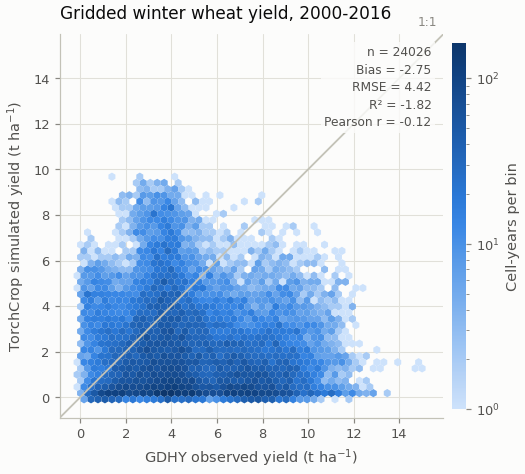

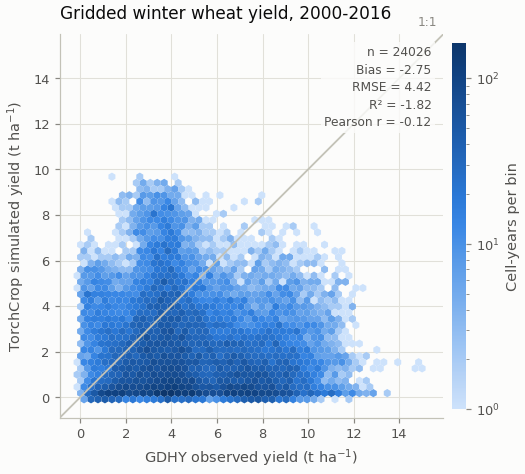

In [7]:
fig = plots.scatter_density(
    paired, "obs_yield", "yield_t_ha", stats=pooled,
    title=f"Gridded winter wheat yield, {paired['year'].min()}-{paired['year'].max()}",
    xlabel="GDHY observed yield (t ha$^{-1}$)",
    ylabel="TorchCrop simulated yield (t ha$^{-1}$)",
)
plots.save(fig, "gdhy_01_scatter_density")
fig

In [20]:
paired

,grid_id,lon,lat,year,yield_t_ha,n_cells,obs_yield,residual
0,178907,-6.25,34.25,2000,0.895540,16,0.461612,0.433928
1,178907,-6.25,34.25,2001,0.798412,16,1.230588,-0.432176
2,178907,-6.25,34.25,2002,0.052055,16,1.117740,-1.065685
3,178907,-6.25,34.25,2003,2.020860,16,1.565227,0.455633
4,178907,-6.25,34.25,2004,1.418009,16,1.944652,-0.526643
...,...,...,...,...,...,...,...,...
24021,213512,16.25,58.25,2012,6.368698,6,8.146414,-1.777716
24022,213512,16.25,58.25,2013,8.634626,6,7.748183,0.886443
24023,213512,16.25,58.25,2014,5.088148,6,7.935102,-2.846954
24024,213512,16.25,58.25,2015,6.173878,6,8.924946,-2.751068


INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_02_map_bias(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_02_map_bias.png')

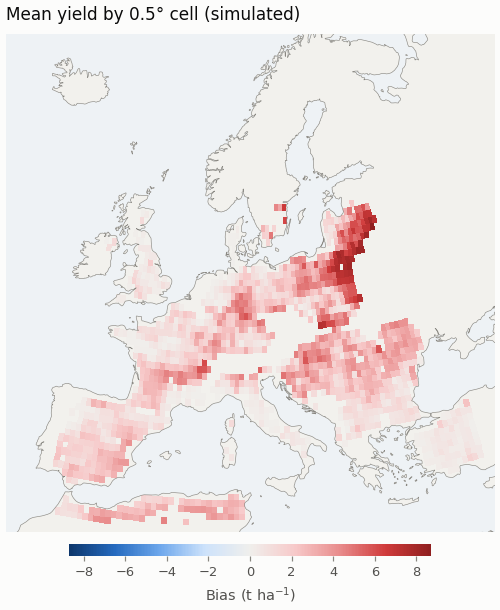

In [25]:
cell_bias = paired.groupby(["grid_id", "lon", "lat"], as_index=False)["yield_t_ha"].mean()

fig = plots.cell_map(
    cell_bias, "yield_t_ha",
    title="Mean yield by 0.5° cell (simulated)",
    cbar_label="Bias (t ha$^{-1}$)", diverging=True,
)
plots.save(fig, "gdhy_02_map_bias")
# fig

This is the map the country-level notebook cannot draw. Compare it with
`outputs/figures/yield_07_map_bias.pdf` — if the two agree at the coastline
where a CyBench country boundary sits, the country-level bias was not hiding a
finer structure; if they disagree, this map is the more honest one.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_03_timeseries(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_03_timeseries.png')

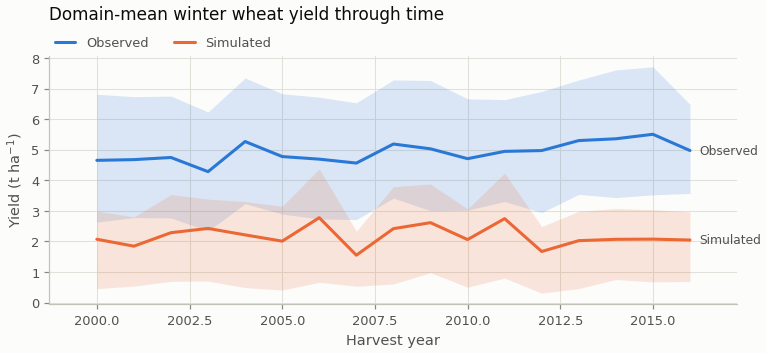

In [22]:
fig = plots.timeseries_pair(
    paired, "obs_yield", "yield_t_ha",
    title="Domain-mean winter wheat yield through time",
    ylabel="Yield (t ha$^{-1}$)",
)
plots.save(fig, "gdhy_03_timeseries")
# fig

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_04_residuals(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_04_residuals.png')

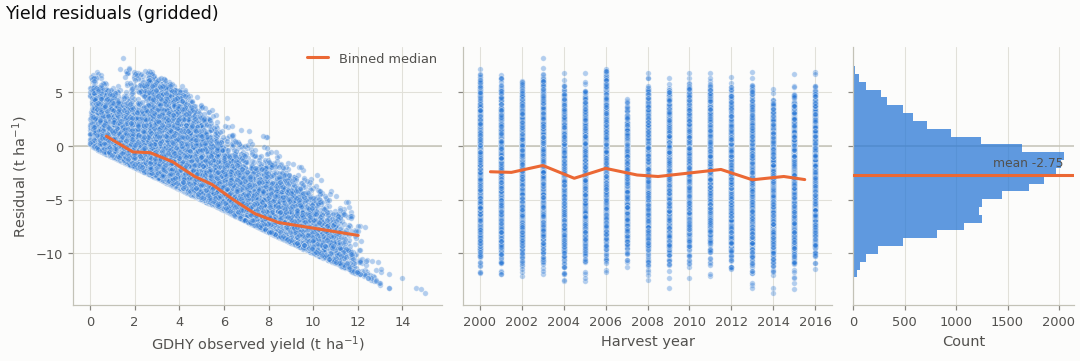

In [23]:
fig = plots.residual_panels(
    paired, "residual", "obs_yield",
    title="Yield residuals (gridded)",
    ylabel="Residual (t ha$^{-1}$)",
    xlabel_obs="GDHY observed yield (t ha$^{-1}$)",
)
plots.save(fig, "gdhy_04_residuals")
# fig

## 7. Spatial signal against interannual signal

Splitting a cell's yield into its long-term mean (spatial) and its deviation
from that mean in a given year (interannual, via `metrics.to_anomalies`)
answers the question §2's caveat raises directly: how much of the correlation
above is "the model puts high-yielding cells where GDHY does" against "the
model's good and bad years line up with GDHY's".

In [11]:
anom = metrics.to_anomalies(paired, ["obs_yield", "yield_t_ha"])

spatial_mean = paired.groupby("grid_id")[["obs_yield", "yield_t_ha"]].mean()
spatial = metrics.yield_metrics(spatial_mean["obs_yield"], spatial_mean["yield_t_ha"])
interannual = metrics.yield_metrics(anom["obs_yield_anom"], anom["yield_t_ha_anom"])

decomposition = pd.DataFrame(
    {"Spatial (cell means)": spatial, "Interannual (anomalies)": interannual}
).T[list(metrics.YIELD_METRIC_ORDER)]
decomposition.round(3)

,n,obs_mean,sim_mean,bias,mae,rmse,mape,r2,pearson_r
Spatial (cell means),1424.0,4.92,2.179,-2.741,3.436,4.284,84.263,-1.80,-0.140
Interannual (anomalies),24026.0,0.00,0.000,-0.000,0.833,1.105,1246.382,-2.09,-0.019


> If the spatial row's `pearson_r` is far from zero and the interannual row's
> is close to it, the model is reproducing *where* GDHY expects high yields but
> not *when* — its year-to-year variation is close to noise relative to GDHY's.
> That is a materially different statement from the pooled r in §5, which
> cannot tell the two apart.

1424 cells with >=5 paired years; 45% have a positive interannual correlation


INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_05_map_interannual_r(.png/.pdf)


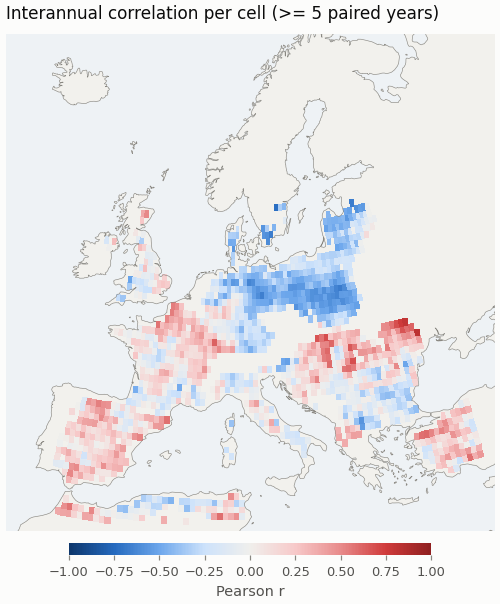

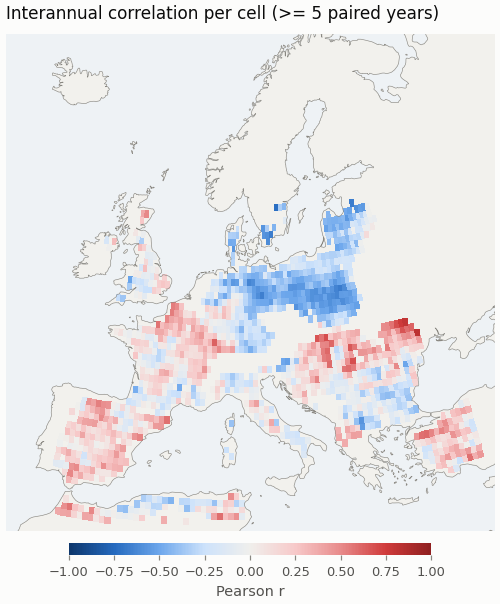

In [12]:
cell_r = (
    anom.groupby("grid_id")
    .apply(lambda g: metrics.yield_metrics(g["obs_yield"], g["yield_t_ha"])["pearson_r"]
           if len(g) >= 5 else np.nan, include_groups=False)
    .rename("interannual_r")
)
cell_pos = paired.groupby(["grid_id", "lon", "lat"], as_index=False).size().drop(columns="size")
cell_pos["interannual_r"] = cell_pos["grid_id"].map(cell_r)

share_positive = float((cell_r.dropna() > 0).mean())
print(f"{cell_r.notna().sum()} cells with >=5 paired years; "
      f"{100 * share_positive:.0f}% have a positive interannual correlation")

fig = plots.cell_map(
    cell_pos.dropna(subset=["interannual_r"]), "interannual_r",
    title="Interannual correlation per cell (>= 5 paired years)",
    cbar_label="Pearson r", diverging=True, vmax=1.0,
)
plots.save(fig, "gdhy_05_map_interannual_r")
fig

## 8. Diagnostics — the run's own state next to the bias

The same diagnostic the country-level notebook runs in its §9, regridded: the
run's state variables, averaged per 0.5° cell, correlated against that cell's
bias.

Correlation of cell bias with the run's own state variables:
obs_yield          -0.85
failed_share       -0.47
n_index            -0.33
grid_id            -0.20
lat                -0.20
days_to_maturity   -0.04
heat                0.24
water_stress        0.37
lon                 0.39
biomass             0.64
sim_yield           0.64
max_lai             0.66


INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/gdhy_06_map_max_lai(.png/.pdf)


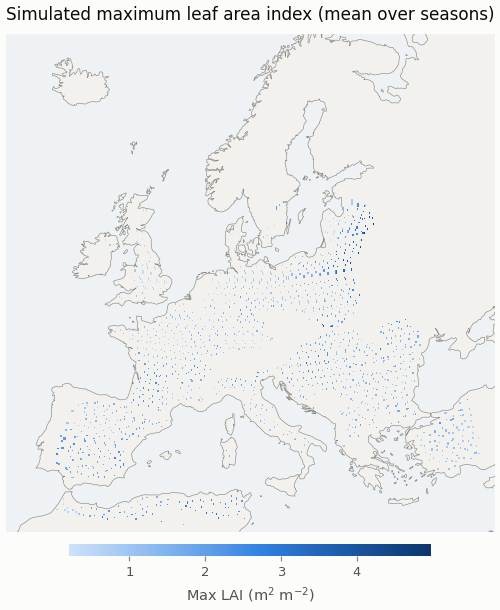

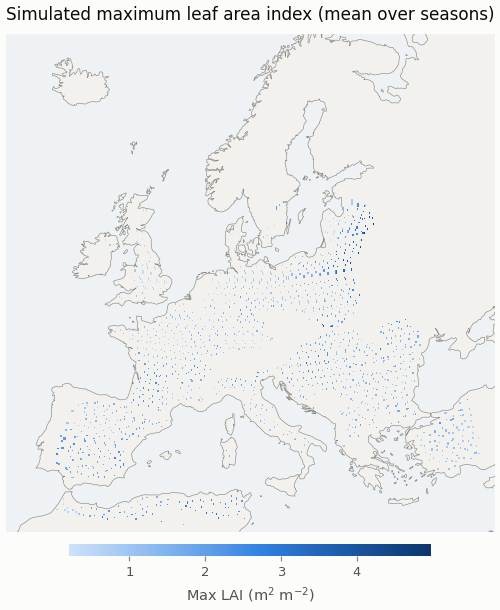

In [13]:
state = (
    sim.groupby("grid_id", as_index=False)
    .agg(lon=("lon", "first"), lat=("lat", "first"),
         max_lai=("max_lai", "mean"), biomass=("biomass_g_m2", "mean"),
         days_to_maturity=("days_to_maturity", "mean"),
         water_stress=("tranrf_mean", "mean"), n_index=("nni_mean", "mean"),
         heat=("heat_stress_factor", "mean"),
         failed_share=("yield_t_ha", lambda s: float((s < 0.5).mean())))
)

state["obs_yield"] = state["grid_id"].map(spatial_mean["obs_yield"])
state["sim_yield"] = state["grid_id"].map(spatial_mean["yield_t_ha"])
state["bias"] = state["sim_yield"] - state["obs_yield"]
state = state.dropna(subset=["bias"])

print("Correlation of cell bias with the run's own state variables:")
print(state.corr(numeric_only=True)["bias"].drop(columns=[], errors="ignore")
      .drop("bias").round(2).sort_values().to_string())

fig = plots.cell_map(
    state, "max_lai",
    title="Simulated maximum leaf area index (mean over seasons)",
    cbar_label="Max LAI (m$^2$ m$^{-2}$)",
)
plots.save(fig, "gdhy_06_map_max_lai")
fig

## 9. Summary

In [14]:
summary = pd.Series({
    "0.5-degree cells": paired["grid_id"].nunique(),
    "cell-years": len(paired),
    "years": f"{paired['year'].min()}-{paired['year'].max()}",
    "observed mean (t/ha)": round(pooled["obs_mean"], 2),
    "simulated mean (t/ha)": round(pooled["sim_mean"], 2),
    "bias (t/ha)": round(pooled["bias"], 2),
    "RMSE (t/ha)": round(pooled["rmse"], 2),
    "pooled Pearson r": round(pooled["pearson_r"], 2),
    "spatial Pearson r": round(spatial["pearson_r"], 2),
    "interannual Pearson r": round(interannual["pearson_r"], 2),
}, name="value")

paired.to_csv(config.TABLE_DIR / "gdhy_paired_cell_year.csv",
              index=False, float_format="%.4f")
decomposition.to_csv(config.TABLE_DIR / "gdhy_spatial_interannual.csv",
                     float_format="%.4f")
state.to_csv(config.TABLE_DIR / "gdhy_diagnostics_by_cell.csv", float_format="%.4f")
print(f"tables written to {config.TABLE_DIR}")
print(f"figures written to {config.FIGURE_DIR}")
summary.to_frame()

tables written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/tables
figures written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures


,value
0.5-degree cells,1424
cell-years,24026
years,2000-2016
observed mean (t/ha),4.92
simulated mean (t/ha),2.17
bias (t/ha),-2.75
RMSE (t/ha),4.42
pooled Pearson r,-0.12
spatial Pearson r,-0.14
interannual Pearson r,-0.02


### What the numbers mean, and what they do not

* **The gridded bias map is the finer-grained twin of `yield_07_map_bias`.**
  Where the two agree, the country-level number was not hiding structure the
  country boundary happens to cut through; where they disagree, trust this one.
* **The pooled correlation is not a skill score.** §7's spatial/interannual
  split is the number to quote for "does the model track a good year" — the
  pooled figure mixes that question with "does the model know where wheat
  yields well", which GDHY answers largely from its own crop mask.
* **A single p-value for the pooled fit would be fiction.** Tens of thousands
  of cell-years are not independent samples; two neighbouring cells share most
  of their signal. No p-value is reported here for that reason — read the
  effect sizes only.
* **The moisture offset from the CyBench notebook still applies.** No
  conversion is applied here either, so part of any negative bias is expected
  before model error is counted.

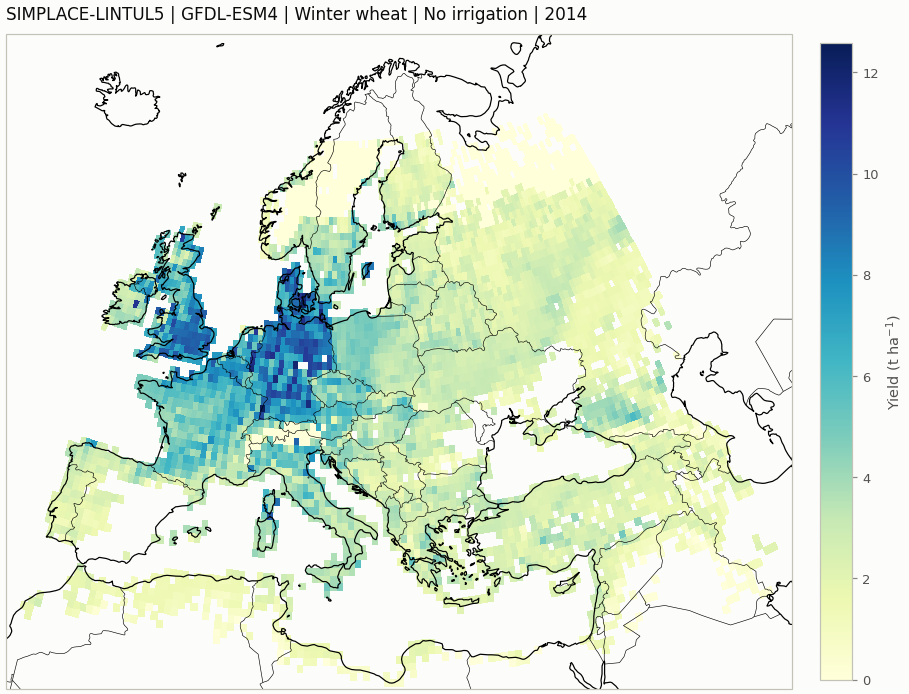

In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# file = "/data01/FDS/muduchuru/Data/Agri/AGRI_ISIMIP/SIMPLACE-LINTUL5/gfdl-esm4/historical/wwh/yield/noirr/simplace-lintul5_gfdl-esm4_w5e5_historical_2015soc_default_yield-wwh-noirr_global_annual-gs_1850_2014.nc"
file = "/data01/FDS/muduchuru/Data/Agri/AGRI_ISIMIP/pDSSAT/gfdl-esm4/historical/wwh/yield/noirr/pdssat_gfdl-esm4_w5e5_historical_2015soc_default_yield-wwh-noirr_global_annual-gs_1850_2014.nc"
# Open without time decoding
ds = xr.open_dataset(file, decode_times=False)

# Variable
da = ds["yield-wwh-noirr"]

# Add real year coordinate
da = da.assign_coords(
    year=("time", da.time.values + 1601)
)

# Select 2014
da = da.where(
    da.year == 2014,
    drop=True
).squeeze("time")

# Sort longitude (already -180 to 180 here)
da = da.sortby("lon")

# Sort latitude north to south
da = da.sortby("lat", ascending=False)

# Europe subset
da = da.sel(
    lat=slice(70, 30),
    lon=slice(-10, 50)
)

# Projection
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=15,
    central_latitude=52
)

fig, ax = plt.subplots(
    figsize=(9, 8),
    subplot_kw={"projection": proj}
)

im = ax.pcolormesh(
    da.lon,
    da.lat,
    da,
    transform=ccrs.PlateCarree(),
    cmap="YlGnBu",
    shading="auto"
)

ax.set_extent(
    [-10, 50, 30, 70],
    crs=ccrs.PlateCarree()
)

ax.coastlines(
    resolution="50m",
    linewidth=0.8
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.4
)

cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.75,
    pad=0.03
)

cbar.set_label("Yield (t ha$^{-1}$)")

ax.set_title(
    "SIMPLACE-LINTUL5 | GFDL-ESM4 | Winter wheat | No irrigation | 2014"
)

plt.tight_layout()
plt.show()